# D_S5 — MIC, MCN, and dCor profiles over 1/SNR

This notebook uses the metrics already computed by `D_S4_snr_sweep_metrics.ipynb`.

The main outputs are:

1. one combined MIC figure containing all selected families;
2. one separate MIC figure for every family;
3. one 1×2 MIC figure separating Group 1 and Group 2;
4. one combined raw-MCN figure containing all selected families;
5. one 1×2 raw-MCN figure separating Group 1 and Group 2;
6. one combined distance-correlation figure containing all selected families.

At every SNR level, one marker shows the mean metric value across five independent repeats; thin lines connect adjacent SNR levels only as visual guides, and the shaded buffer shows ±1 standard deviation across repeats. The noise-free cases (`1/SNR = 0`) are retained as the leftmost baseline, and a symmetric-log x-axis preserves both zero and the logarithmic finite-SNR range. Three boolean switches control whether the `mild`, `standard`, and `strong` variants are included; the default displays only `strong`.

`MCN` is plotted on the raw scale returned by `minepy` (lower values indicate a smaller grid is sufficient to capture near-MIC dependence). It is not normalized in this notebook.

In [1]:
from __future__ import annotations

import json
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

try:
    from IPython.display import display
except ImportError:
    display = print

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

## Load D_S3 case metadata and D_S4 metrics

In [2]:
RUN_MODE = os.environ.get('SNR_SWEEP_MODE', 'full').strip().lower()
if RUN_MODE not in {'full', 'pilot'}:
    raise ValueError("SNR_SWEEP_MODE must be 'full' or 'pilot'")

def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D' / 'Global').is_dir():
            return root
    raise FileNotFoundError('Could not locate D/Global')

REPO_ROOT = locate_repo_root()
GLOBAL_DIR = REPO_ROOT / 'D' / 'Global'
BASE_DATA_DIR = GLOBAL_DIR / 'output' / 'S3_snr_mic_sweep'
DATA_DIR = BASE_DATA_DIR if RUN_MODE == 'full' else BASE_DATA_DIR / '_pilot'
FIGURE_DIR = DATA_DIR / 'metric_scatterplots'

CASES_PATH = DATA_DIR / 'cases.csv'
METRICS_PATH = DATA_DIR / 'metrics_full.parquet'
missing = [path for path in [CASES_PATH, METRICS_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Run D_S3 and D_S4 first. Missing: ' + ', '.join(map(str, missing))
    )

cases_df = pd.read_csv(CASES_PATH, low_memory=False)
metrics_df = pd.read_parquet(
    METRICS_PATH,
    columns=['case_id', 'MIC', 'MCN', 'distance_correlation'],
)
plot_df = cases_df.merge(metrics_df, on='case_id', how='left', validate='one_to_one')

required_columns = [
    'case_id', 'family_id', 'family_name', 'variant_level',
    'nominal_snr', 'inverse_snr', 'repeat', 'is_null',
    'MIC', 'MCN', 'distance_correlation',
]
missing_columns = [column for column in required_columns if column not in plot_df.columns]
assert not missing_columns, missing_columns
assert len(plot_df) == len(cases_df) == len(metrics_df)
assert plot_df[['MIC', 'MCN', 'distance_correlation']].notna().all().all()

signal_df = plot_df.loc[~plot_df['is_null']].copy()
null_df = plot_df.loc[plot_df['is_null']].copy()
assert signal_df['inverse_snr'].notna().all()
assert null_df['inverse_snr'].isna().all()

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'RUN_MODE: {RUN_MODE}')
print(f'Cases: {len(signal_df):,} signal + {len(null_df):,} Null')
print(f'Families: {signal_df["family_id"].nunique()}')
print(f'Output: {FIGURE_DIR}')
display(signal_df[['family_id', 'variant_level', 'nominal_snr', 'repeat', 'MIC', 'MCN', 'distance_correlation']].head())

RUN_MODE: full
Cases: 95,340 signal + 100 Null
Families: 14
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/metric_scatterplots


,family_id,variant_level,nominal_snr,repeat,MIC,MCN,distance_correlation
0,F01,mild,0.001000,1,0.164492,5.321928,0.085222
1,F01,mild,0.001068,1,0.151321,5.321928,0.085829
2,F01,mild,0.001141,1,0.144934,5.321928,0.086465
3,F01,mild,0.001219,1,0.144934,5.321928,0.087130
4,F01,mild,0.001302,1,0.147350,5.321928,0.087825


## Shared plotting settings

In [3]:
# Three display switches. Default: strong only.
SHOW_MILD = False
SHOW_STANDARD = False
SHOW_STRONG = True
REPEATS_TO_AGGREGATE = (1, 2, 3, 4, 5)
DISPLAY_FIGURES_INLINE = True

VARIANT_SWITCHES = {
    'mild': SHOW_MILD,
    'standard': SHOW_STANDARD,
    'strong': SHOW_STRONG,
}
ACTIVE_VARIANTS = [variant for variant, enabled in VARIANT_SWITCHES.items() if enabled]
if not ACTIVE_VARIANTS:
    raise ValueError('At least one of SHOW_MILD, SHOW_STANDARD, or SHOW_STRONG must be True.')

FAMILY_ORDER = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
METRICS = [('MIC', 'MIC')]
VARIANT_STYLE = {
    'mild': {'marker': 'o', 'linestyle': ':'},
    'standard': {'marker': '^', 'linestyle': '--'},
    'strong': {'marker': 's', 'linestyle': '-'},
}

filtered_signal_df = signal_df[
    signal_df['variant_level'].isin(ACTIVE_VARIANTS)
    & signal_df['repeat'].isin(REPEATS_TO_AGGREGATE)
].copy()
plot_signal_df = filtered_signal_df.copy()

# Every family × variant × SNR center is based on exactly five independent repeats.
repeat_counts = plot_signal_df.groupby(
    ['family_id', 'variant_level', 'inverse_snr'], dropna=False
).size()
if not repeat_counts.eq(len(REPEATS_TO_AGGREGATE)).all():
    bad_counts = repeat_counts[~repeat_counts.eq(len(REPEATS_TO_AGGREGATE))]
    raise ValueError(f'Expected five repeats per plotted point; mismatches:\n{bad_counts.head(20)}')

positive_inverse_snr = plot_signal_df.loc[
    plot_signal_df['inverse_snr'] > 0, 'inverse_snr'
]
MIN_POSITIVE_INVERSE_SNR = float(positive_inverse_snr.min())
MAX_INVERSE_SNR = float(positive_inverse_snr.max())
SYMLOG_LINTHRESH = MIN_POSITIVE_INVERSE_SNR / 2.0

print('Active variants:', ACTIVE_VARIANTS)
print(f'Repeats aggregated: {REPEATS_TO_AGGREGATE}')
print(f'Signal cases summarized: {len(plot_signal_df):,}')
print(f'Noise-free cases included: {(plot_signal_df["inverse_snr"] == 0).sum():,}')

Active variants: ['strong']
Repeats aggregated: (1, 2, 3, 4, 5)
Signal cases summarized: 15,890
Noise-free cases included: 70


## Generate one MIC figure per family

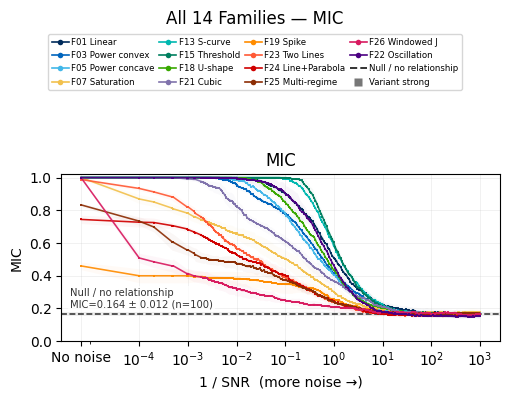

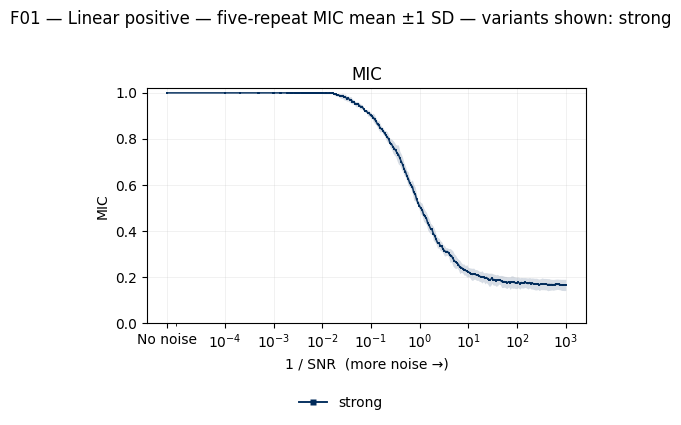

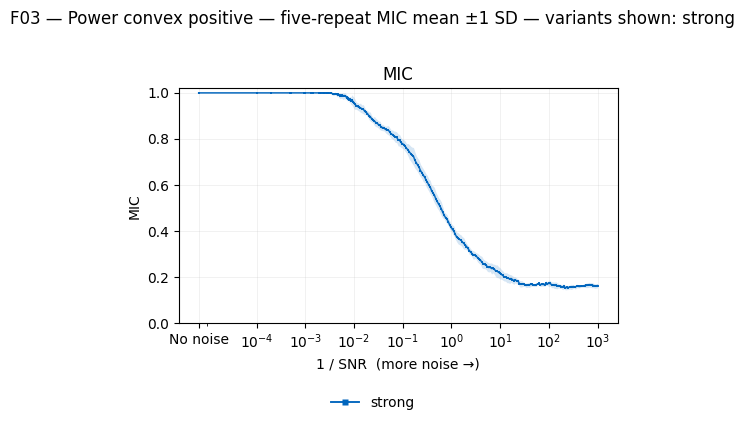

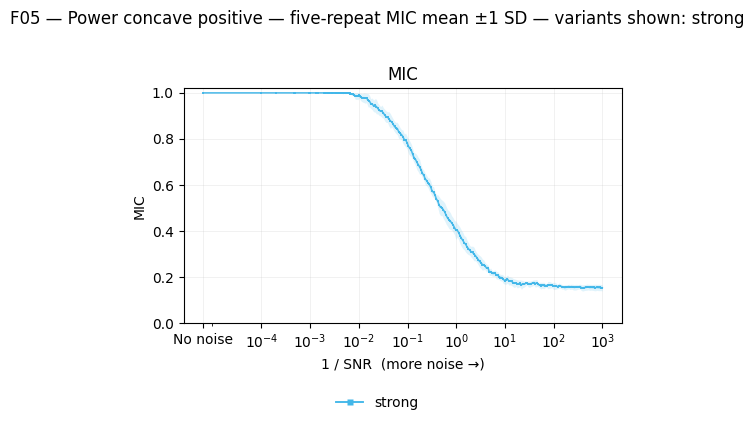

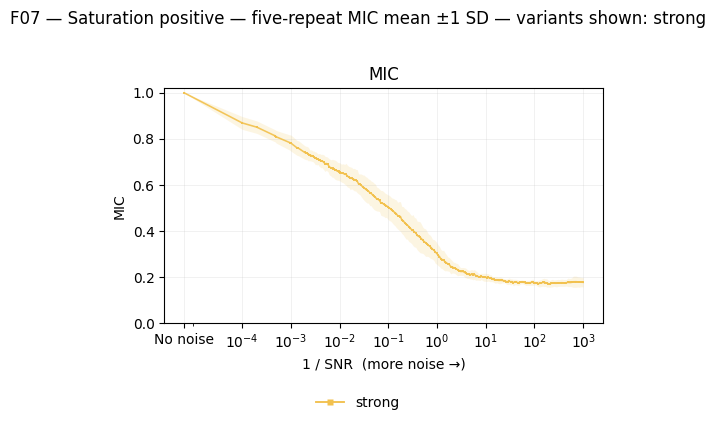

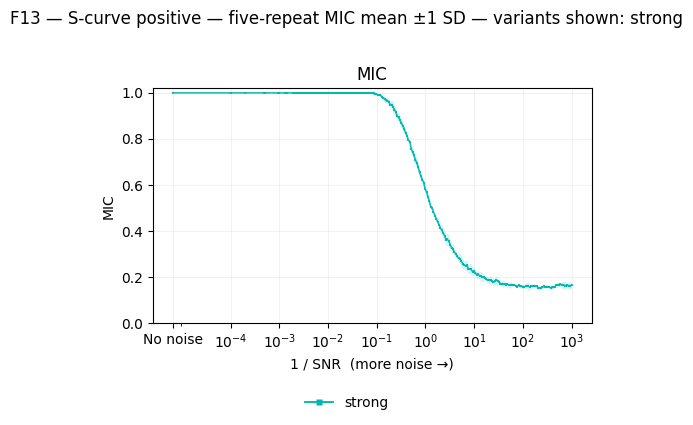

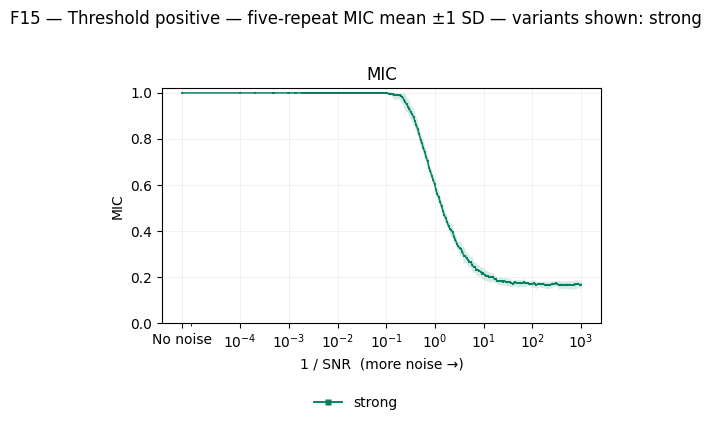

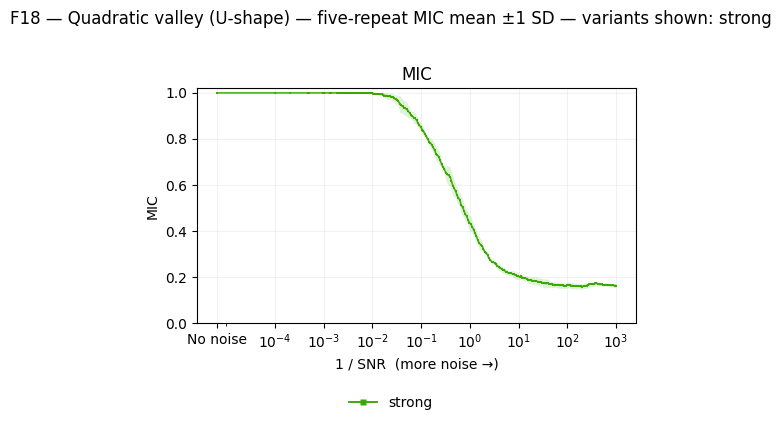

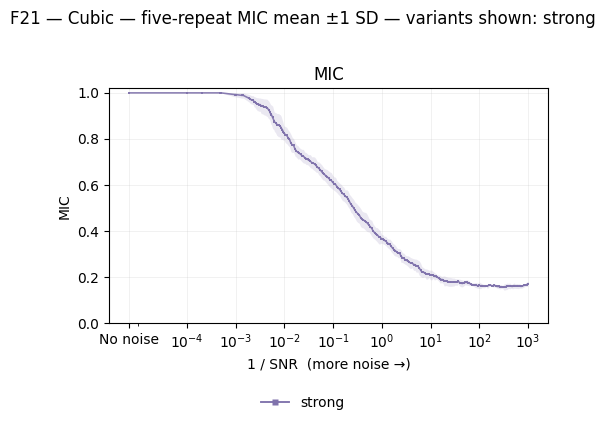

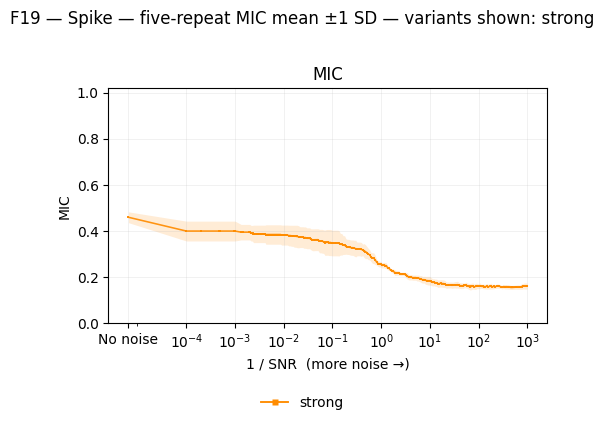

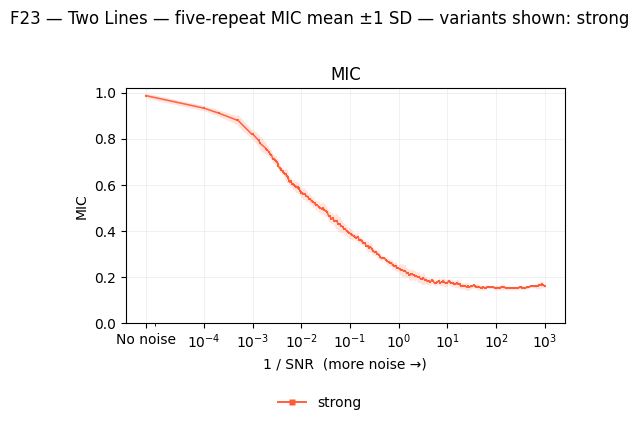

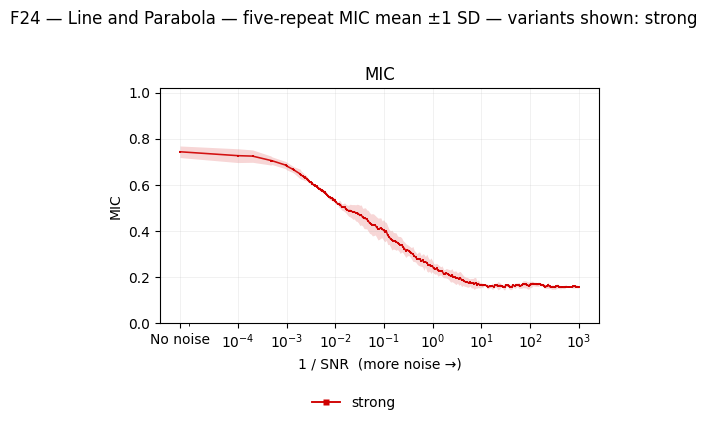

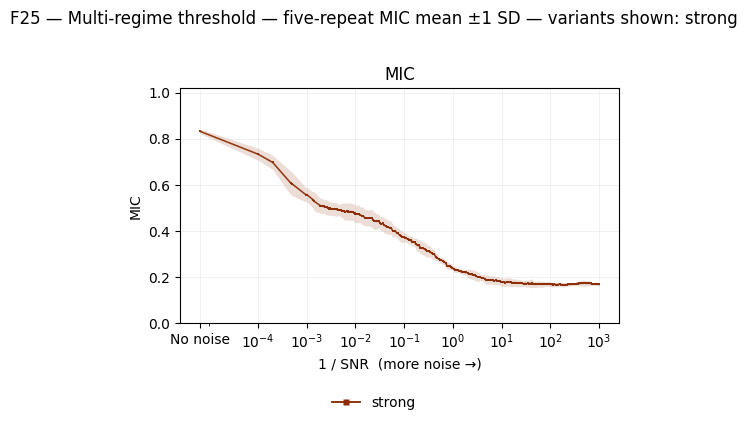

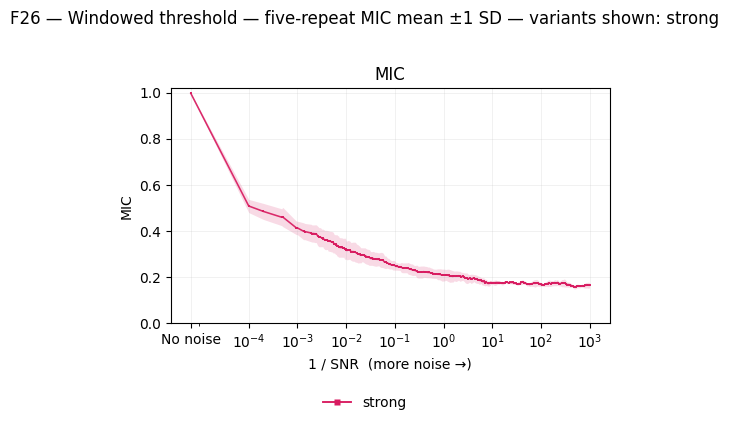

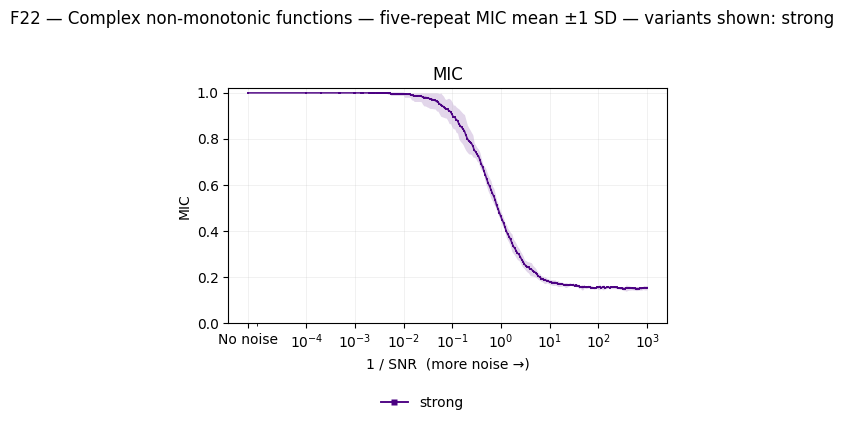

Saved 1 combined MIC + 14 family MIC figures and figure_manifest.csv


,figure_scope,family_id,family_name,variants,n_signal_cases,figure_path
0,all_families_mic,ALL,All selected families — MIC,strong,15890,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,single_family_mic,F01,Linear positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
2,single_family_mic,F03,Power convex positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
3,single_family_mic,F05,Power concave positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
4,single_family_mic,F07,Saturation positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
5,single_family_mic,F13,S-curve positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
6,single_family_mic,F15,Threshold positive,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
7,single_family_mic,F18,Quadratic valley (U-shape),strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
8,single_family_mic,F21,Cubic,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...
9,single_family_mic,F19,Spike,strong,1135,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [4]:
def format_metric_axis(ax, metric_label: str) -> None:
    ax.set_xscale('symlog', base=10, linthresh=SYMLOG_LINTHRESH, linscale=0.8)
    decade_min = int(np.floor(np.log10(MIN_POSITIVE_INVERSE_SNR)))
    decade_max = int(np.ceil(np.log10(MAX_INVERSE_SNR)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ticks = np.concatenate(([0.0], decade_ticks))
    tick_labels = ['No noise'] + [
        rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)
    ]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel('1 / SNR  (more noise →)')
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label)
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.20, linewidth=0.6)


def summarize_repeat_means(points: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    summary = (
        points.groupby('inverse_snr', as_index=False)[metric_name]
        .agg(mean='mean', sd='std', n='size')
        .sort_values('inverse_snr')
    )
    if not summary['n'].eq(len(REPEATS_TO_AGGREGATE)).all():
        raise ValueError(f'{metric_name}: every SNR level must contain five repeats.')
    return summary


def draw_mean_scatter(
    ax,
    points: pd.DataFrame,
    metric_name: str,
    color,
    marker: str,
    linestyle: str,
    buffer_alpha: float,
) -> None:
    summary = summarize_repeat_means(points, metric_name)
    x = summary['inverse_snr'].to_numpy(float)
    mean = summary['mean'].to_numpy(float)
    sd = summary['sd'].fillna(0.0).to_numpy(float)
    lower = np.clip(mean - sd, 0.0, 1.0)
    upper = np.clip(mean + sd, 0.0, 1.0)
    ax.fill_between(
        x, lower, upper, color=color, alpha=buffer_alpha, linewidth=0, zorder=1,
    )
    ax.plot(
        x, mean, color=color, linestyle=linestyle, linewidth=1.15,
        marker=marker, markersize=2.0, markeredgewidth=0,
        alpha=0.92, zorder=3,
    )


available_families = [fid for fid in FAMILY_ORDER if fid in signal_df['family_id'].unique()]
# Fixed family colors used consistently in every overview, group, and family figure.
# Group 1 uses cool hues; Group 2 uses warm hues.
FAMILY_COLORS = {
    # Group 1 — cool
    'F01': '#002B5B',  # very dark navy
    'F03': '#0065BD',  # saturated royal blue
    'F05': '#42B7E9',  # bright sky blue
    'F13': '#00B8B0',  # bright cyan-teal
    'F15': '#007F5F',  # dark teal
    'F18': '#38A800',  # vivid green
    'F21': '#8073AC',  # light purple
    'F22': '#4B0082',  # deep violet
    # Group 2 — warm
    'F07': '#F2C14E',  # bright gold
    'F19': '#FF8C00',  # vivid orange
    'F23': '#FF5A36',  # bright coral
    'F24': '#D00000',  # saturated red
    'F25': '#8C2D04',  # dark burnt brown
    'F26': '#D81B60',  # hot pink
}
missing_family_colors = sorted(set(available_families) - set(FAMILY_COLORS))
assert not missing_family_colors, missing_family_colors
FAMILY_SHORT_LABELS = {
    'F01': 'F01 Linear', 'F03': 'F03 Power convex', 'F05': 'F05 Power concave',
    'F07': 'F07 Saturation', 'F13': 'F13 S-curve', 'F15': 'F15 Threshold',
    'F18': 'F18 U-shape', 'F21': 'F21 Cubic', 'F19': 'F19 Spike',
    'F23': 'F23 Two Lines', 'F24': 'F24 Line+Parabola',
    'F25': 'F25 Multi-regime', 'F26': 'F26 Windowed J', 'F22': 'F22 Oscillation',
}

NULL_REFERENCE_COLOR = '#333333'

def draw_null_metric_reference(ax, metric_name: str) -> tuple[float, float, int]:
    values = null_df[metric_name].dropna()
    mean = float(values.mean())
    sd = float(values.std())
    n = int(values.size)
    ax.axhspan(
        max(0.0, mean - sd), min(1.0, mean + sd),
        color=NULL_REFERENCE_COLOR, alpha=0.08, linewidth=0, zorder=0,
    )
    ax.axhline(mean, color=NULL_REFERENCE_COLOR, linestyle='--', linewidth=1.15, zorder=2)
    label_y = min(0.92, (mean + sd + 0.018) / 1.02)
    ax.text(
        0.02, label_y, f'Null / no relationship\n{metric_name}={mean:.3f} ± {sd:.3f} (n={n})',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=7.2,
        color=NULL_REFERENCE_COLOR, zorder=4,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.5},
    )
    return mean, sd, n

# 1) One combined MIC figure containing every selected family.
fig, ax = plt.subplots(figsize=(5.2, 4.0))
for family_id in available_families:
    family_data = plot_signal_df[plot_signal_df['family_id'] == family_id]
    for variant in ACTIVE_VARIANTS:
        points = family_data[family_data['variant_level'] == variant]
        if points.empty:
            continue
        style = VARIANT_STYLE[variant]
        draw_mean_scatter(
            ax, points, 'MIC', FAMILY_COLORS[family_id],
            marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.035,
        )
# Format first so the Null reference does not expand the data x-limits.
format_metric_axis(ax, 'MIC')
draw_null_metric_reference(ax, 'MIC')

family_handles = [
    Line2D([0], [0], marker='o', linestyle='-', color=FAMILY_COLORS[family_id],
           markerfacecolor=FAMILY_COLORS[family_id], markeredgecolor='none',
           linewidth=1.2, markersize=4, label=FAMILY_SHORT_LABELS[family_id])
    for family_id in available_families
]
overview_handles = family_handles + [
    Line2D([0], [0], linestyle='--', color=NULL_REFERENCE_COLOR, linewidth=1.4,
           label='Null / no relationship'),
] + [
    Line2D([0], [0], marker=VARIANT_STYLE[variant]['marker'], linestyle='None',
           markerfacecolor='#777777', markeredgecolor='none', markersize=6,
           label=f'Variant {variant}')
    for variant in ACTIVE_VARIANTS
]
fig.suptitle(f'All {len(available_families)} Families — MIC', y=0.995)
fig.legend(
    handles=overview_handles, loc='upper center', bbox_to_anchor=(0.5, 0.945),
    ncol=4, frameon=True, fontsize=6.2, handletextpad=0.25, columnspacing=0.55,
)
fig.tight_layout(rect=[0, 0.01, 1, 0.76])
overview_path = FIGURE_DIR / 'ALL_FAMILIES_mic_vs_inverse_snr.png'
old_overview_path = FIGURE_DIR / 'ALL_FAMILIES_mic_dcor_vs_inverse_snr.png'
old_overview_path.unlink(missing_ok=True)
fig.savefig(overview_path, dpi=300, bbox_inches='tight')
if DISPLAY_FIGURES_INLINE:
    display(fig)
plt.close(fig)

manifest_rows = [{
    'figure_scope': 'all_families_mic',
    'family_id': 'ALL',
    'family_name': 'All selected families — MIC',
    'variants': ','.join(ACTIVE_VARIANTS),
    'n_signal_cases': int(len(plot_signal_df)),
    'figure_path': str(overview_path),
}]

# 2) One compact MIC figure for every family.
for family_id in available_families:
    family_data = plot_signal_df[plot_signal_df['family_id'] == family_id].copy()
    family_name = family_data['family_name'].iloc[0]

    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    for variant in ACTIVE_VARIANTS:
        points = family_data[family_data['variant_level'] == variant]
        if points.empty:
            continue
        style = VARIANT_STYLE[variant]
        draw_mean_scatter(
            ax, points, 'MIC', FAMILY_COLORS[family_id],
            marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.16,
        )
    format_metric_axis(ax, 'MIC')

    fig.suptitle(
        f'{family_id} — {family_name} — five-repeat MIC mean ±1 SD — '
        f'variants shown: {", ".join(ACTIVE_VARIANTS)}',
        y=1.02,
    )
    family_variant_handles = [
        Line2D(
            [0], [0], marker=VARIANT_STYLE[variant]['marker'],
            linestyle=VARIANT_STYLE[variant]['linestyle'],
            color=FAMILY_COLORS[family_id],
            markerfacecolor=FAMILY_COLORS[family_id], markeredgecolor='none',
            linewidth=1.35, markersize=5, label=variant,
        )
        for variant in ACTIVE_VARIANTS
    ]
    fig.legend(
        handles=family_variant_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
        ncol=max(1, len(family_variant_handles)), frameon=False,
    )
    fig.tight_layout(rect=[0, 0.08, 1, 1])

    figure_path = FIGURE_DIR / f'{family_id}_mic_vs_inverse_snr.png'
    old_figure_path = FIGURE_DIR / f'{family_id}_mic_dcor_vs_inverse_snr.png'
    old_figure_path.unlink(missing_ok=True)
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    if DISPLAY_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    manifest_rows.append({
        'figure_scope': 'single_family_mic',
        'family_id': family_id,
        'family_name': family_name,
        'variants': ','.join(ACTIVE_VARIANTS),
        'n_signal_cases': int(len(family_data)),
        'figure_path': str(figure_path),
    })

figure_manifest = pd.DataFrame(manifest_rows)
manifest_path = FIGURE_DIR / 'figure_manifest.csv'
figure_manifest.to_csv(manifest_path, index=False)

assert len(figure_manifest) == len(available_families) + 1
assert all(Path(path).exists() and Path(path).stat().st_size > 0 for path in figure_manifest['figure_path'])
print(f'Saved 1 combined MIC + {len(available_families)} family MIC figures and {manifest_path.name}')
display(figure_manifest)

## Grouped MIC profiles: Group 1 and Group 2

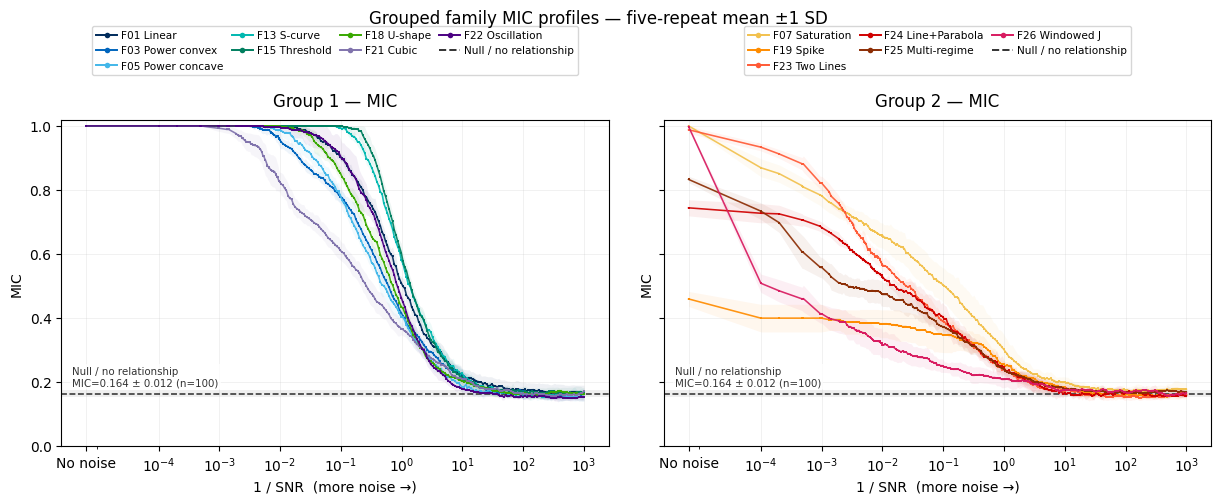

Saved grouped MIC 1x2 figure; updated figure_manifest.csv


,figure_scope,family_id,family_name,variants,n_signal_cases,figure_path
0,family_group_1x2_mic,"Group1=F01,F03,F05,F13,F15,F18,F21,F22; Group2...",Group 1 cool / Group 2 warm — MIC 1x2,strong,15890,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [5]:
PRIMARY_GROUP = ['F01', 'F03', 'F05', 'F13', 'F15', 'F18', 'F21', 'F22']
REMAINING_GROUP = [family_id for family_id in available_families if family_id not in PRIMARY_GROUP]
GROUP_SPECS = [
    ('group_1_selected', PRIMARY_GROUP, 'Group 1 — F01, F03, F05, F13, F15, F18, F21, F22'),
    ('group_2_remaining', REMAINING_GROUP, 'Group 2 — remaining families'),
]
assert set(PRIMARY_GROUP).isdisjoint(REMAINING_GROUP)
assert set(PRIMARY_GROUP) | set(REMAINING_GROUP) == set(available_families)
assert len(PRIMARY_GROUP) == 8 and len(REMAINING_GROUP) == 6

null_mic_values = null_df['MIC'].dropna()
NULL_MIC_MEAN = float(null_mic_values.mean())
NULL_MIC_SD = float(null_mic_values.std())
NULL_MIC_N = int(null_mic_values.size)
NULL_COLOR = '#333333'
NULL_LEGEND_LABEL = 'Null / no relationship'
NULL_VALUE_LABEL = f'Null / no relationship\nMIC={NULL_MIC_MEAN:.3f} ± {NULL_MIC_SD:.3f} (n={NULL_MIC_N})'

fig, axes = plt.subplots(1, len(GROUP_SPECS), figsize=(12.5, 4.6), sharex=True, sharey=True)
for group_index, ((_, group_families, _), ax) in enumerate(zip(GROUP_SPECS, axes), start=1):
    for family_id in group_families:
        family_data = plot_signal_df[plot_signal_df['family_id'] == family_id]
        for variant in ACTIVE_VARIANTS:
            points = family_data[family_data['variant_level'] == variant]
            if points.empty:
                continue
            style = VARIANT_STYLE[variant]
            draw_mean_scatter(
                ax, points, 'MIC', FAMILY_COLORS[family_id],
                marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.065,
            )

    format_metric_axis(ax, 'MIC')
    ax.axhspan(
        max(0.0, NULL_MIC_MEAN - NULL_MIC_SD), min(1.0, NULL_MIC_MEAN + NULL_MIC_SD),
        color=NULL_COLOR, alpha=0.08, linewidth=0, zorder=0,
    )
    ax.axhline(NULL_MIC_MEAN, color=NULL_COLOR, linestyle='--', linewidth=1.15, zorder=2)
    ax.text(
        0.02, 0.18, NULL_VALUE_LABEL, transform=ax.transAxes, ha='left', va='bottom',
        fontsize=7.4, color=NULL_COLOR, zorder=4,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.5},
    )

    ax.set_title(f'Group {group_index} — MIC', pad=10)
    handles = [
        Line2D(
            [0], [0], marker='o', linestyle='-', color=FAMILY_COLORS[family_id],
            markerfacecolor=FAMILY_COLORS[family_id], markeredgecolor='none',
            linewidth=1.4, markersize=4, label=FAMILY_SHORT_LABELS[family_id],
        )
        for family_id in group_families
    ] + [
        Line2D([0], [0], linestyle='--', color=NULL_COLOR, linewidth=1.4, label=NULL_LEGEND_LABEL),
    ]
    ax.legend(
        handles=handles, loc='lower center', bbox_to_anchor=(0.5, 1.12),
        ncol=4 if group_index == 1 else 3, frameon=True,
        fontsize=7.6, handletextpad=0.35, columnspacing=0.8,
    )

fig.suptitle('Grouped family MIC profiles — five-repeat mean ±1 SD', y=1.09)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.14, top=0.85, wspace=0.10)

group_path = FIGURE_DIR / 'grouped_families_1x2_mic_vs_inverse_snr.png'
old_group_path = FIGURE_DIR / 'grouped_families_2x2_mic_dcor_vs_inverse_snr.png'
old_group_path.unlink(missing_ok=True)
fig.savefig(group_path, dpi=300, bbox_inches='tight')
if DISPLAY_FIGURES_INLINE:
    display(fig)
plt.close(fig)

group_manifest = pd.DataFrame([{
    'figure_scope': 'family_group_1x2_mic',
    'family_id': 'Group1=' + ','.join(PRIMARY_GROUP) + '; Group2=' + ','.join(REMAINING_GROUP),
    'family_name': 'Group 1 cool / Group 2 warm — MIC 1x2',
    'variants': ','.join(ACTIVE_VARIANTS),
    'n_signal_cases': int(len(plot_signal_df)),
    'figure_path': str(group_path),
}])
figure_manifest = figure_manifest.loc[
    ~figure_manifest['figure_scope'].isin(['family_group', 'family_group_2x2', 'family_group_1x2_mic'])
].copy()
figure_manifest = pd.concat([figure_manifest, group_manifest], ignore_index=True)
figure_manifest.to_csv(manifest_path, index=False)
assert len(figure_manifest) == len(available_families) + 2
assert group_path.exists() and group_path.stat().st_size > 0
print(f'Saved grouped MIC 1x2 figure; updated {manifest_path.name}')
display(group_manifest)

## MCN profiles: all families and Group 1 / Group 2

These figures use the raw `MCN` values already computed in D_S4. The curves show five-repeat mean ±1 SD; no MCN normalization is applied.

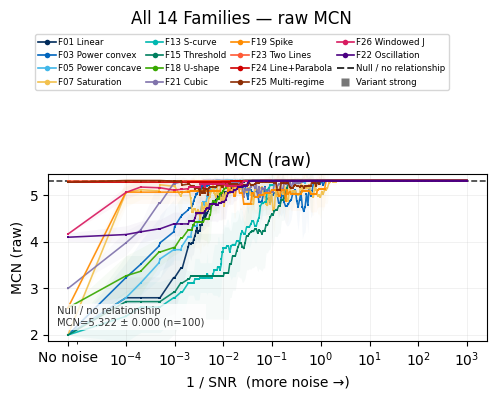

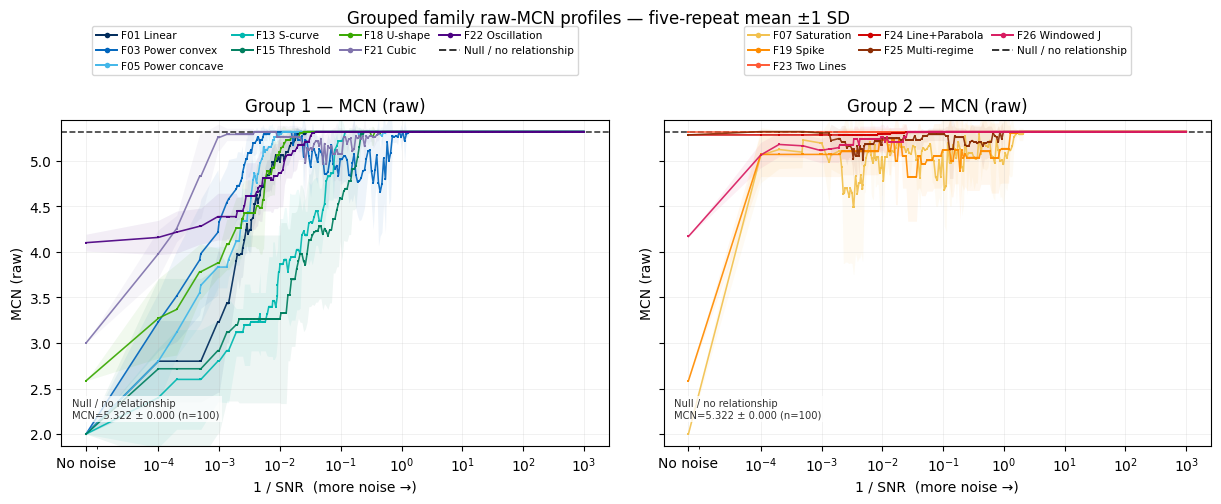

Saved combined MCN figure and grouped MCN 1x2 figure; updated figure_manifest.csv


,figure_scope,family_id,family_name,variants,n_signal_cases,figure_path
0,all_families_mcn,ALL,All selected families — raw MCN,strong,15890,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,family_group_1x2_mcn,"Group1=F01,F03,F05,F13,F15,F18,F21,F22; Group2...",Group 1 cool / Group 2 warm — raw MCN 1x2,strong,15890,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [6]:
def format_mcn_axis(ax, title: str) -> None:
    ax.set_xscale('symlog', base=10, linthresh=SYMLOG_LINTHRESH, linscale=0.8)
    decade_min = int(np.floor(np.log10(MIN_POSITIVE_INVERSE_SNR)))
    decade_max = int(np.ceil(np.log10(MAX_INVERSE_SNR)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ticks = np.concatenate(([0.0], decade_ticks))
    tick_labels = ['No noise'] + [
        rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)
    ]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(MCN_Y_MIN, MCN_Y_MAX)
    ax.set_xlabel('1 / SNR  (more noise →)')
    ax.set_ylabel('MCN (raw)')
    ax.set_title(title)
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.20, linewidth=0.6)


MCN_DATA_MIN = float(min(plot_signal_df['MCN'].min(), null_df['MCN'].min()))
MCN_DATA_MAX = float(max(plot_signal_df['MCN'].max(), null_df['MCN'].max()))
MCN_PADDING = max(0.12, 0.04 * (MCN_DATA_MAX - MCN_DATA_MIN))
MCN_Y_MIN = MCN_DATA_MIN - MCN_PADDING
MCN_Y_MAX = MCN_DATA_MAX + MCN_PADDING


def draw_mcn_scatter(
    ax,
    points: pd.DataFrame,
    color,
    marker: str,
    linestyle: str,
    buffer_alpha: float,
) -> None:
    summary = summarize_repeat_means(points, 'MCN')
    x = summary['inverse_snr'].to_numpy(float)
    mean = summary['mean'].to_numpy(float)
    sd = summary['sd'].fillna(0.0).to_numpy(float)
    ax.fill_between(
        x, mean - sd, mean + sd,
        color=color, alpha=buffer_alpha, linewidth=0, zorder=1,
    )
    ax.plot(
        x, mean, color=color, linestyle=linestyle, linewidth=1.15,
        marker=marker, markersize=2.0, markeredgewidth=0,
        alpha=0.92, zorder=3,
    )


NULL_MCN_VALUES = null_df['MCN'].dropna()
NULL_MCN_MEAN = float(NULL_MCN_VALUES.mean())
NULL_MCN_SD = float(NULL_MCN_VALUES.std())
NULL_MCN_N = int(NULL_MCN_VALUES.size)
NULL_MCN_LABEL = f'Null / no relationship\nMCN={NULL_MCN_MEAN:.3f} ± {NULL_MCN_SD:.3f} (n={NULL_MCN_N})'


def draw_null_mcn_reference(ax, label_position=(0.02, 0.08)) -> None:
    ax.axhspan(
        NULL_MCN_MEAN - NULL_MCN_SD, NULL_MCN_MEAN + NULL_MCN_SD,
        color=NULL_REFERENCE_COLOR, alpha=0.08, linewidth=0, zorder=0,
    )
    ax.axhline(
        NULL_MCN_MEAN, color=NULL_REFERENCE_COLOR,
        linestyle='--', linewidth=1.15, zorder=2,
    )
    ax.text(
        *label_position, NULL_MCN_LABEL, transform=ax.transAxes,
        ha='left', va='bottom', fontsize=7.2,
        color=NULL_REFERENCE_COLOR, zorder=4,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.5},
    )


# 1) All families together — raw MCN.
fig, ax = plt.subplots(figsize=(5.2, 4.0))
for family_id in available_families:
    family_data = plot_signal_df[plot_signal_df['family_id'] == family_id]
    for variant in ACTIVE_VARIANTS:
        points = family_data[family_data['variant_level'] == variant]
        if points.empty:
            continue
        style = VARIANT_STYLE[variant]
        draw_mcn_scatter(
            ax, points, FAMILY_COLORS[family_id],
            marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.035,
        )
# Format first so the Null reference does not expand the data x-limits.
format_mcn_axis(ax, 'MCN (raw)')
draw_null_mcn_reference(ax)

mcn_overview_handles = family_handles + [
    Line2D([0], [0], linestyle='--', color=NULL_REFERENCE_COLOR, linewidth=1.4,
           label='Null / no relationship'),
] + [
    Line2D([0], [0], marker=VARIANT_STYLE[variant]['marker'], linestyle='None',
           markerfacecolor='#777777', markeredgecolor='none', markersize=6,
           label=f'Variant {variant}')
    for variant in ACTIVE_VARIANTS
]
fig.suptitle(f'All {len(available_families)} Families — raw MCN', y=0.995)
fig.legend(
    handles=mcn_overview_handles, loc='upper center', bbox_to_anchor=(0.5, 0.945),
    ncol=4, frameon=True, fontsize=6.2, handletextpad=0.25, columnspacing=0.55,
)
fig.tight_layout(rect=[0, 0.01, 1, 0.76])
mcn_overview_path = FIGURE_DIR / 'ALL_FAMILIES_mcn_vs_inverse_snr.png'
fig.savefig(mcn_overview_path, dpi=300, bbox_inches='tight')
if DISPLAY_FIGURES_INLINE:
    display(fig)
plt.close(fig)


# 2) Group 1 and Group 2 side by side — raw MCN.
fig, axes = plt.subplots(1, len(GROUP_SPECS), figsize=(12.5, 4.6), sharex=True, sharey=True)
for group_index, ((_, group_families, _), ax) in enumerate(zip(GROUP_SPECS, axes), start=1):
    for family_id in group_families:
        family_data = plot_signal_df[plot_signal_df['family_id'] == family_id]
        for variant in ACTIVE_VARIANTS:
            points = family_data[family_data['variant_level'] == variant]
            if points.empty:
                continue
            style = VARIANT_STYLE[variant]
            draw_mcn_scatter(
                ax, points, FAMILY_COLORS[family_id],
                marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.065,
            )

    format_mcn_axis(ax, f'Group {group_index} — MCN (raw)')
    draw_null_mcn_reference(ax)
    handles = [
        Line2D(
            [0], [0], marker='o', linestyle='-', color=FAMILY_COLORS[family_id],
            markerfacecolor=FAMILY_COLORS[family_id], markeredgecolor='none',
            linewidth=1.4, markersize=4, label=FAMILY_SHORT_LABELS[family_id],
        )
        for family_id in group_families
    ] + [
        Line2D([0], [0], linestyle='--', color=NULL_REFERENCE_COLOR,
               linewidth=1.4, label='Null / no relationship'),
    ]
    ax.legend(
        handles=handles, loc='lower center', bbox_to_anchor=(0.5, 1.12),
        ncol=4 if group_index == 1 else 3, frameon=True,
        fontsize=7.6, handletextpad=0.35, columnspacing=0.8,
    )

fig.suptitle('Grouped family raw-MCN profiles — five-repeat mean ±1 SD', y=1.09)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.14, top=0.85, wspace=0.10)
mcn_group_path = FIGURE_DIR / 'grouped_families_1x2_mcn_vs_inverse_snr.png'
fig.savefig(mcn_group_path, dpi=300, bbox_inches='tight')
if DISPLAY_FIGURES_INLINE:
    display(fig)
plt.close(fig)

mcn_manifest = pd.DataFrame([
    {
        'figure_scope': 'all_families_mcn',
        'family_id': 'ALL',
        'family_name': 'All selected families — raw MCN',
        'variants': ','.join(ACTIVE_VARIANTS),
        'n_signal_cases': int(len(plot_signal_df)),
        'figure_path': str(mcn_overview_path),
    },
    {
        'figure_scope': 'family_group_1x2_mcn',
        'family_id': 'Group1=' + ','.join(PRIMARY_GROUP) + '; Group2=' + ','.join(REMAINING_GROUP),
        'family_name': 'Group 1 cool / Group 2 warm — raw MCN 1x2',
        'variants': ','.join(ACTIVE_VARIANTS),
        'n_signal_cases': int(len(plot_signal_df)),
        'figure_path': str(mcn_group_path),
    },
])
figure_manifest = figure_manifest.loc[
    ~figure_manifest['figure_scope'].isin(['all_families_mcn', 'family_group_1x2_mcn'])
].copy()
figure_manifest = pd.concat([figure_manifest, mcn_manifest], ignore_index=True)
figure_manifest.to_csv(manifest_path, index=False)

assert len(figure_manifest) == len(available_families) + 4
assert mcn_overview_path.exists() and mcn_overview_path.stat().st_size > 0
assert mcn_group_path.exists() and mcn_group_path.stat().st_size > 0
print('Saved combined MCN figure and grouped MCN 1x2 figure; updated figure_manifest.csv')
display(mcn_manifest)

## Distance-correlation profile: all families

This standalone overview uses the same 14 family colors and the same five-repeat mean ±1 SD construction as the combined MIC figure. The x-axis is `1/SNR`, and the y-axis is distance correlation (`dCor`). The Null mean ±1 SD is retained as a reference.

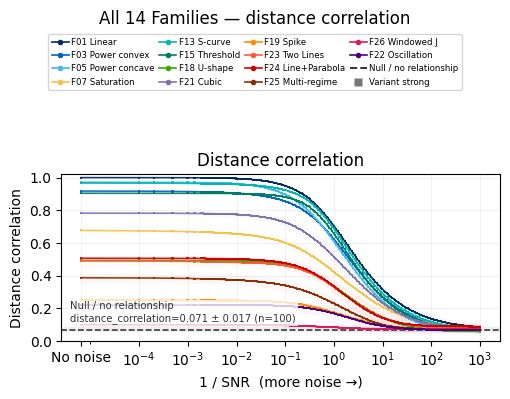

Saved standalone all-family dCor figure; updated figure_manifest.csv


,figure_scope,family_id,family_name,variants,n_signal_cases,figure_path
0,all_families_dcor,ALL,All selected families — distance correlation,strong,15890,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [7]:
# Standalone all-family distance-correlation overview.
fig, ax = plt.subplots(figsize=(5.2, 4.0))
for family_id in available_families:
    family_data = plot_signal_df[plot_signal_df['family_id'] == family_id]
    for variant in ACTIVE_VARIANTS:
        points = family_data[family_data['variant_level'] == variant]
        if points.empty:
            continue
        style = VARIANT_STYLE[variant]
        draw_mean_scatter(
            ax, points, 'distance_correlation', FAMILY_COLORS[family_id],
            marker=style['marker'], linestyle=style['linestyle'], buffer_alpha=0.035,
        )

# Format before adding the horizontal Null reference so the reference does not
# expand the symlog x-limits.
format_metric_axis(ax, 'Distance correlation')
draw_null_metric_reference(ax, 'distance_correlation')

dcor_overview_handles = family_handles + [
    Line2D([0], [0], linestyle='--', color=NULL_REFERENCE_COLOR, linewidth=1.4,
           label='Null / no relationship'),
] + [
    Line2D([0], [0], marker=VARIANT_STYLE[variant]['marker'], linestyle='None',
           markerfacecolor='#777777', markeredgecolor='none', markersize=6,
           label=f'Variant {variant}')
    for variant in ACTIVE_VARIANTS
]
fig.suptitle(f'All {len(available_families)} Families — distance correlation', y=0.995)
fig.legend(
    handles=dcor_overview_handles, loc='upper center', bbox_to_anchor=(0.5, 0.945),
    ncol=4, frameon=True, fontsize=6.2, handletextpad=0.25, columnspacing=0.55,
)
fig.tight_layout(rect=[0, 0.01, 1, 0.76])
dcor_overview_path = FIGURE_DIR / 'ALL_FAMILIES_dcor_vs_inverse_snr.png'
fig.savefig(dcor_overview_path, dpi=300, bbox_inches='tight')
if DISPLAY_FIGURES_INLINE:
    display(fig)
plt.close(fig)

dcor_manifest = pd.DataFrame([{
    'figure_scope': 'all_families_dcor',
    'family_id': 'ALL',
    'family_name': 'All selected families — distance correlation',
    'variants': ','.join(ACTIVE_VARIANTS),
    'n_signal_cases': int(len(plot_signal_df)),
    'figure_path': str(dcor_overview_path),
}])
figure_manifest = figure_manifest.loc[
    ~figure_manifest['figure_scope'].eq('all_families_dcor')
].copy()
figure_manifest = pd.concat([figure_manifest, dcor_manifest], ignore_index=True)
figure_manifest.to_csv(manifest_path, index=False)

assert len(figure_manifest) == len(available_families) + 5
assert dcor_overview_path.exists() and dcor_overview_path.stat().st_size > 0
print('Saved standalone all-family dCor figure; updated figure_manifest.csv')
display(dcor_manifest)

## Grouped scatterplot checks at MIC = 0.8, 0.6, 0.4 and SNR = 1, 10, 0.5

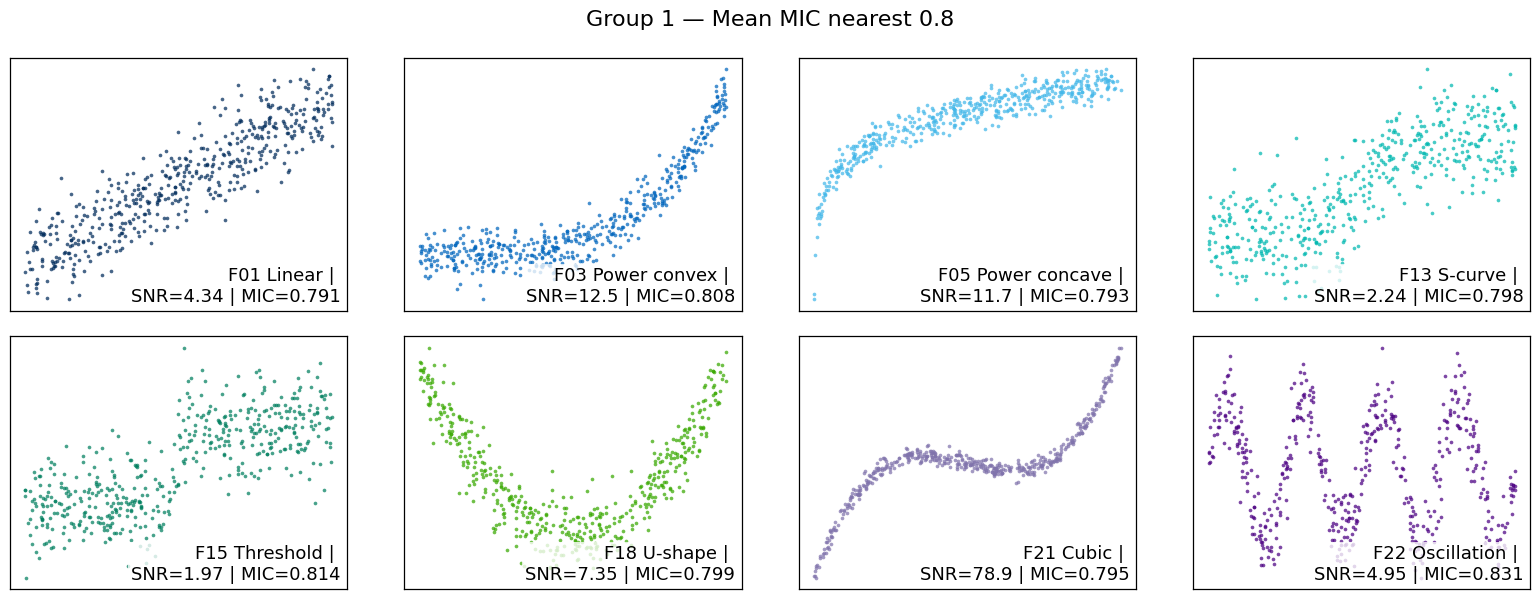

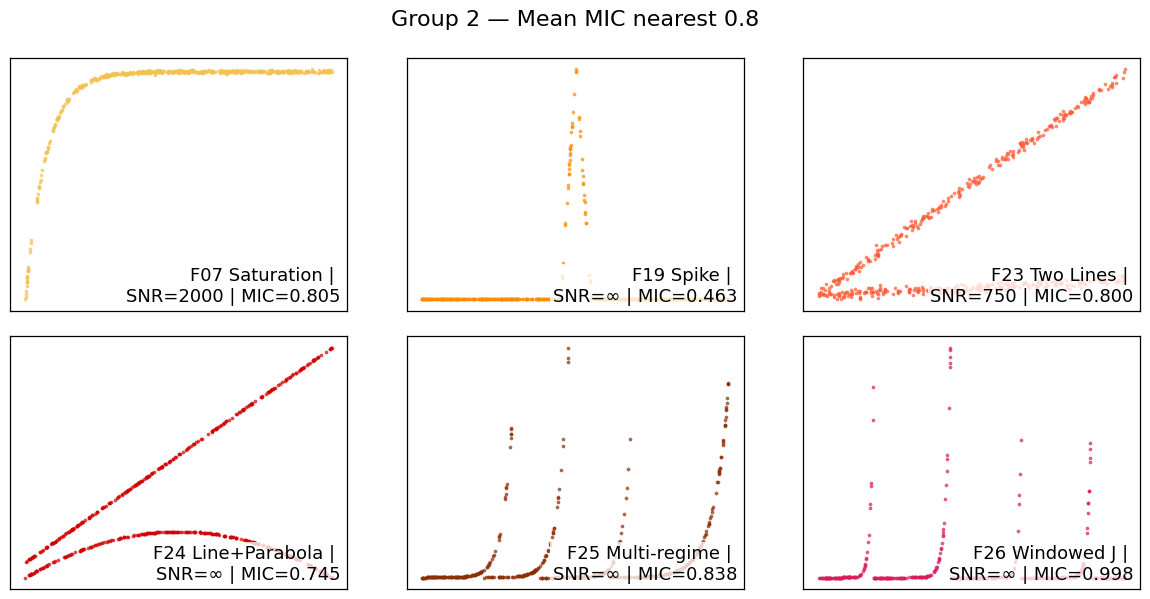

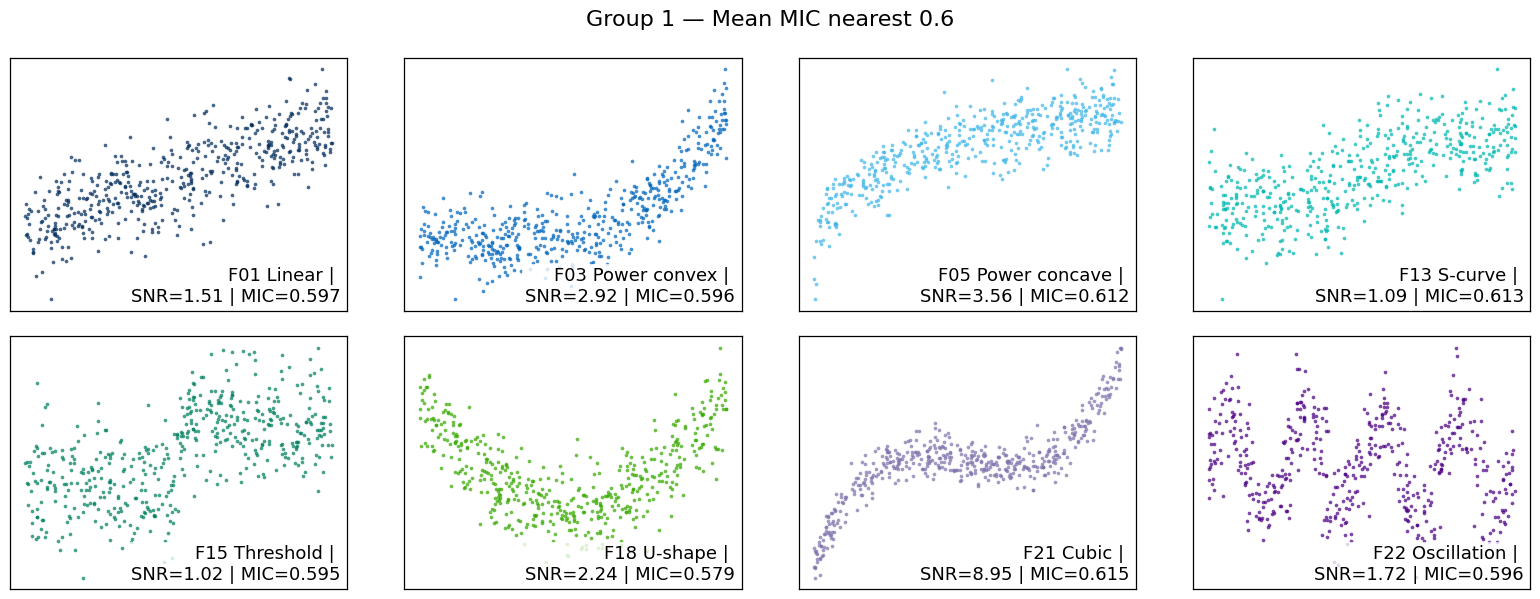

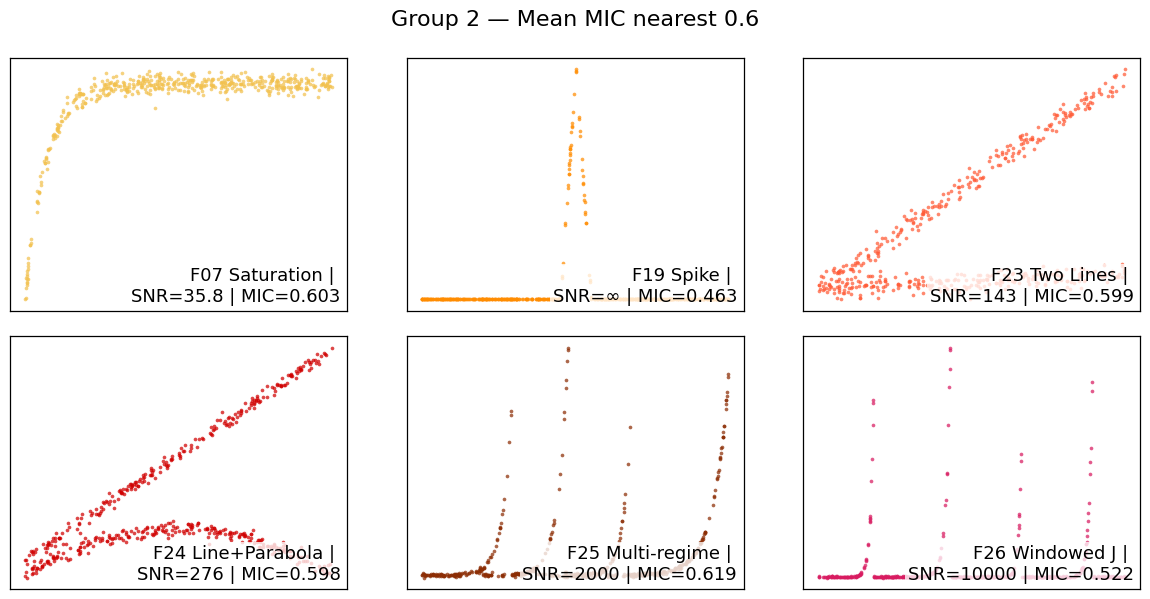

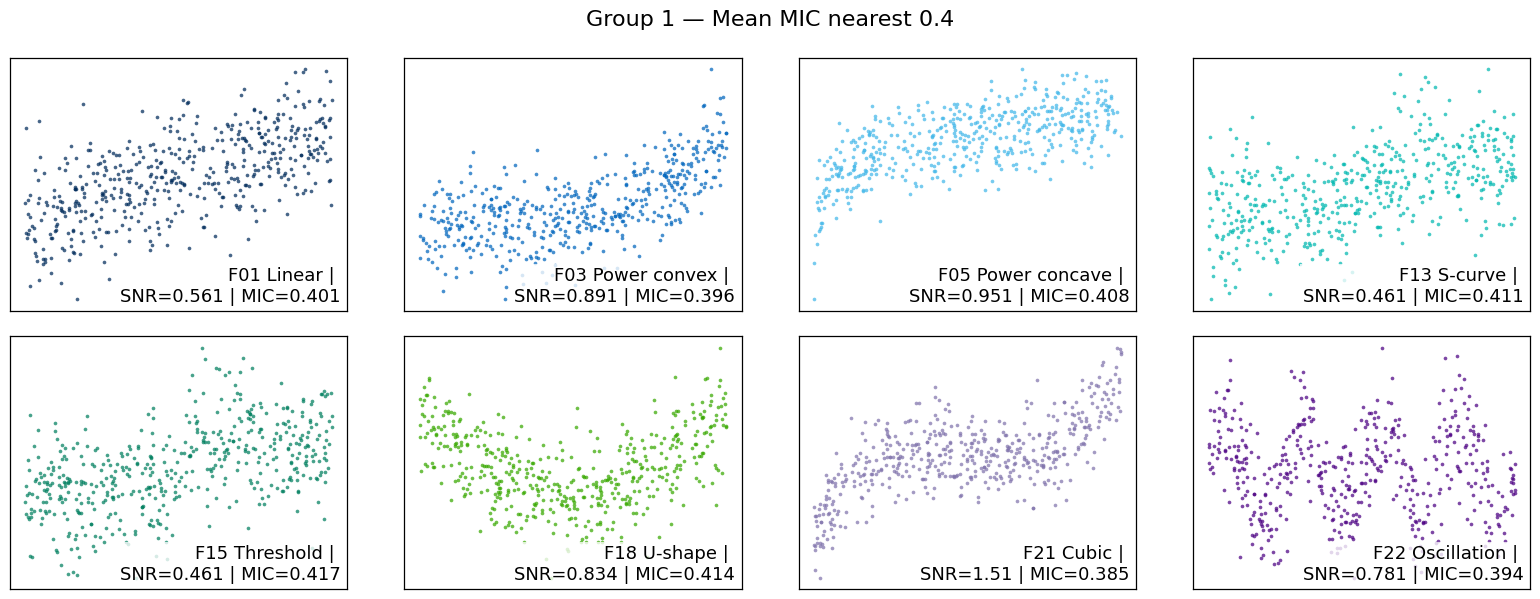

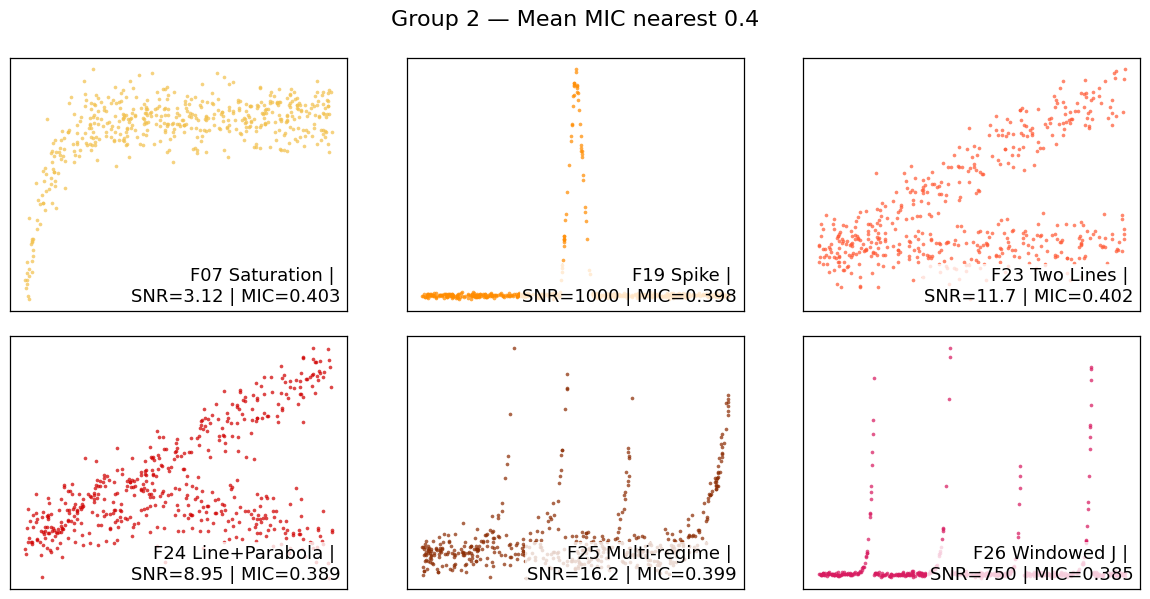

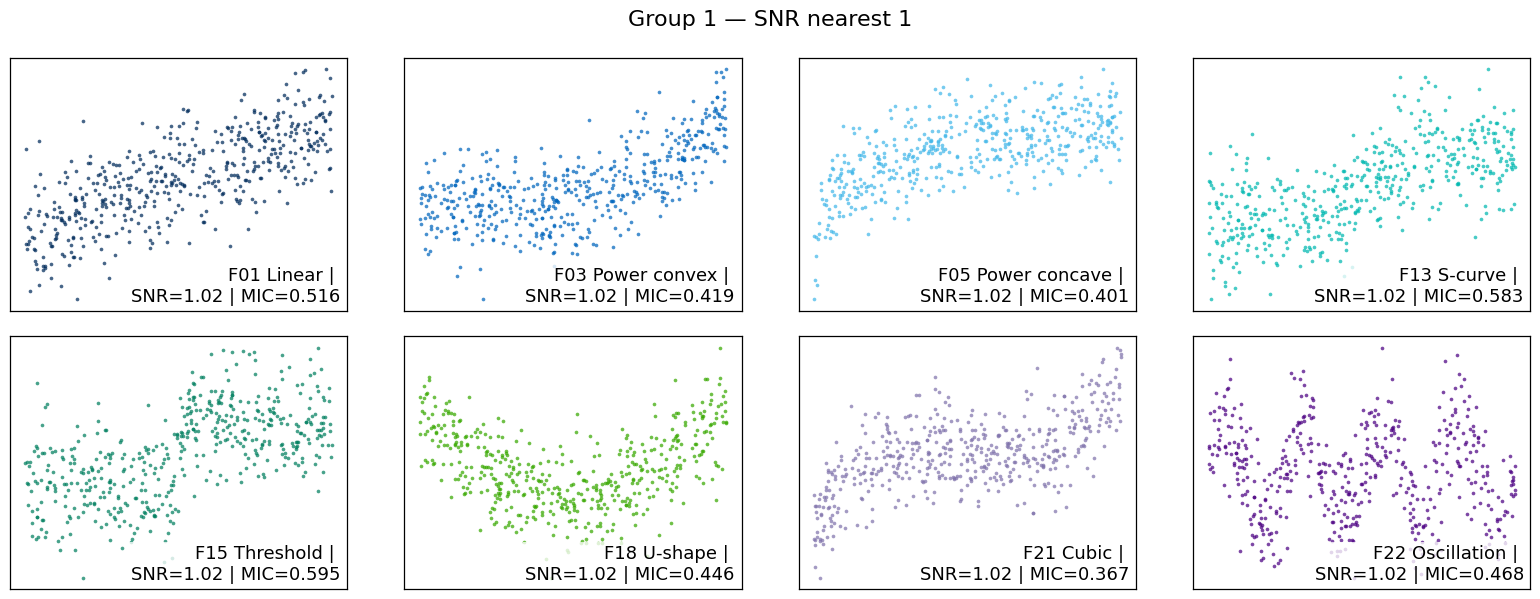

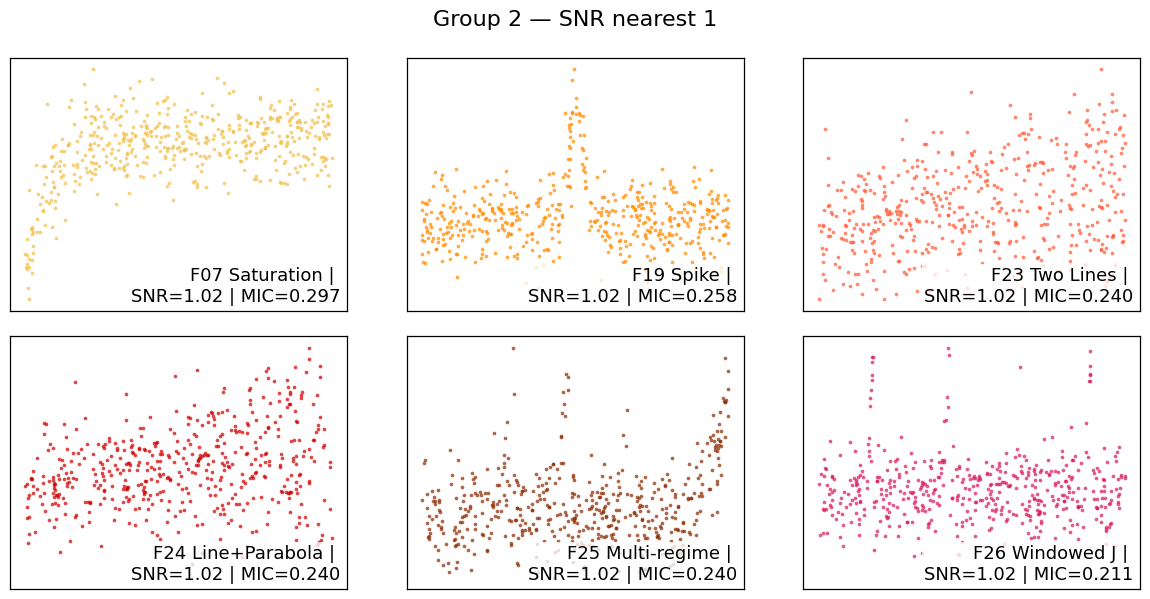

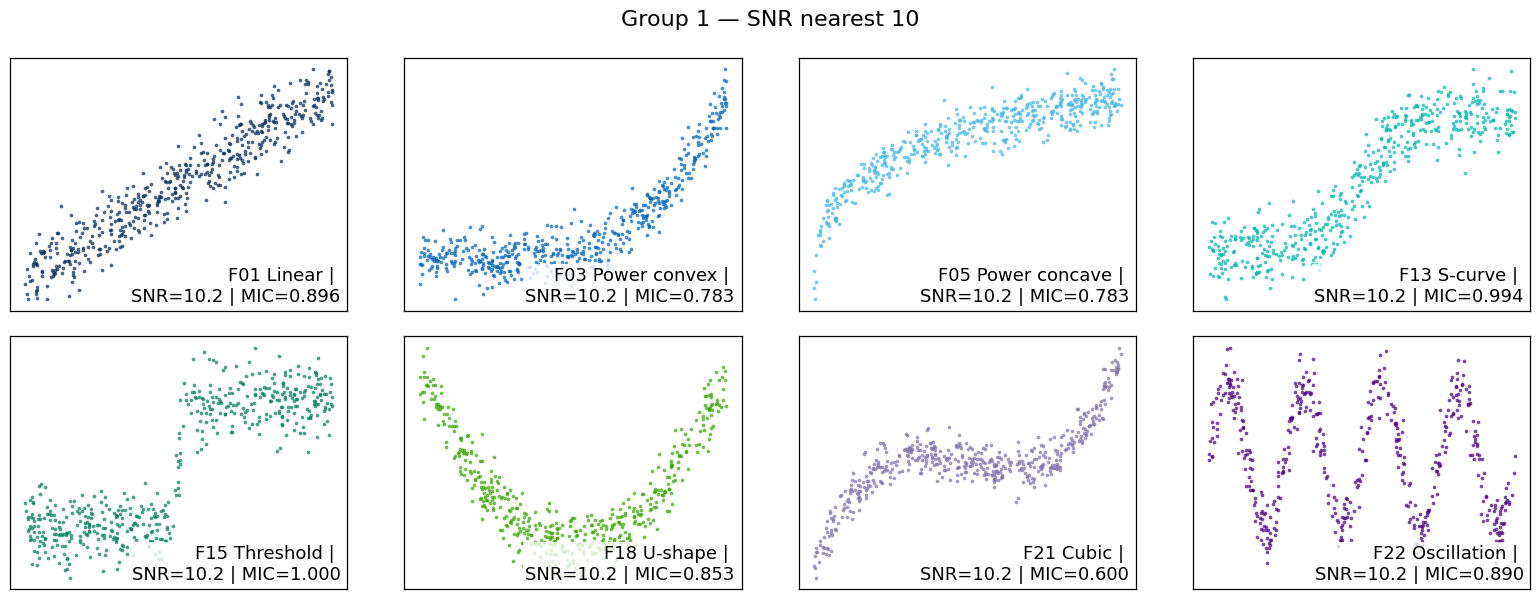

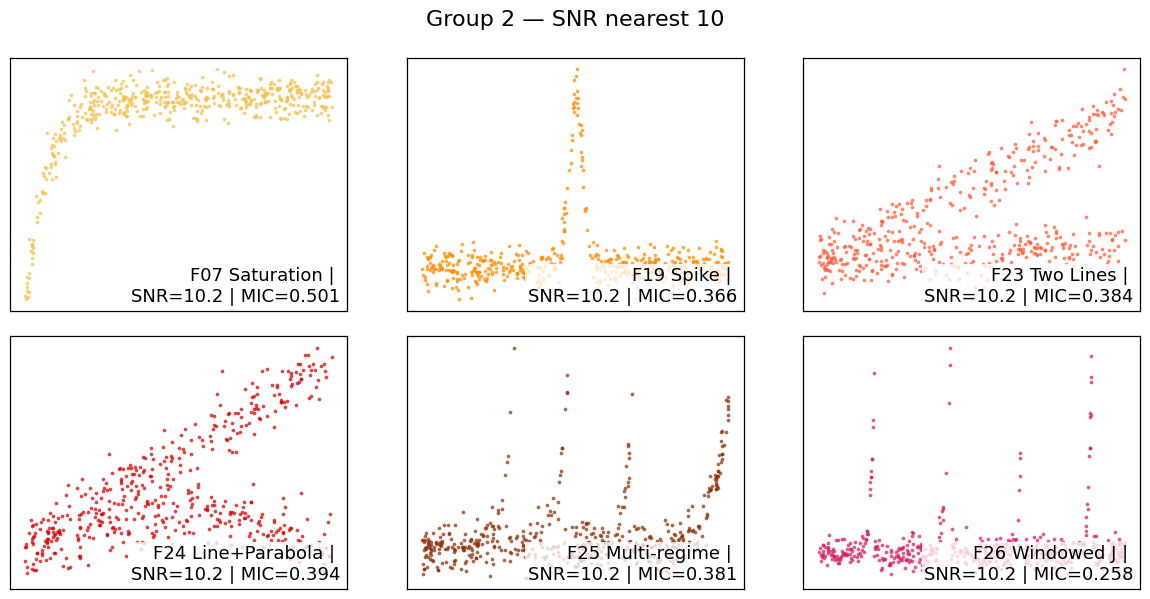

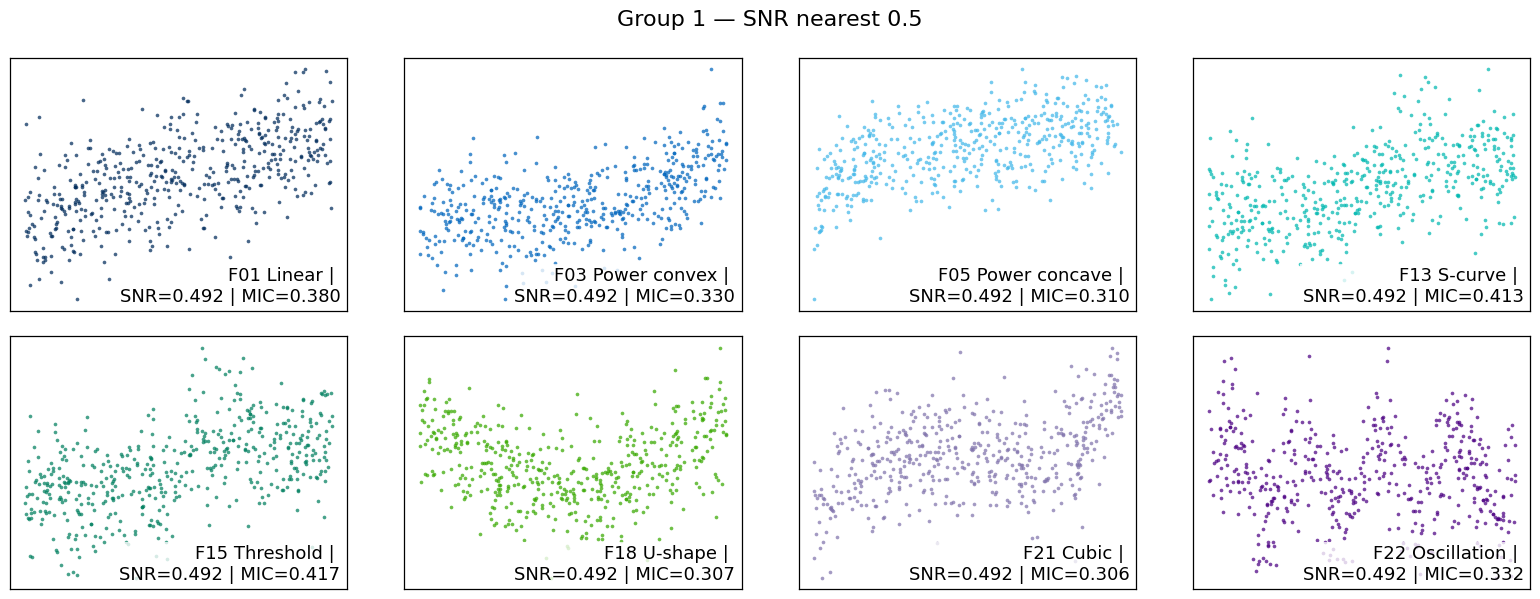

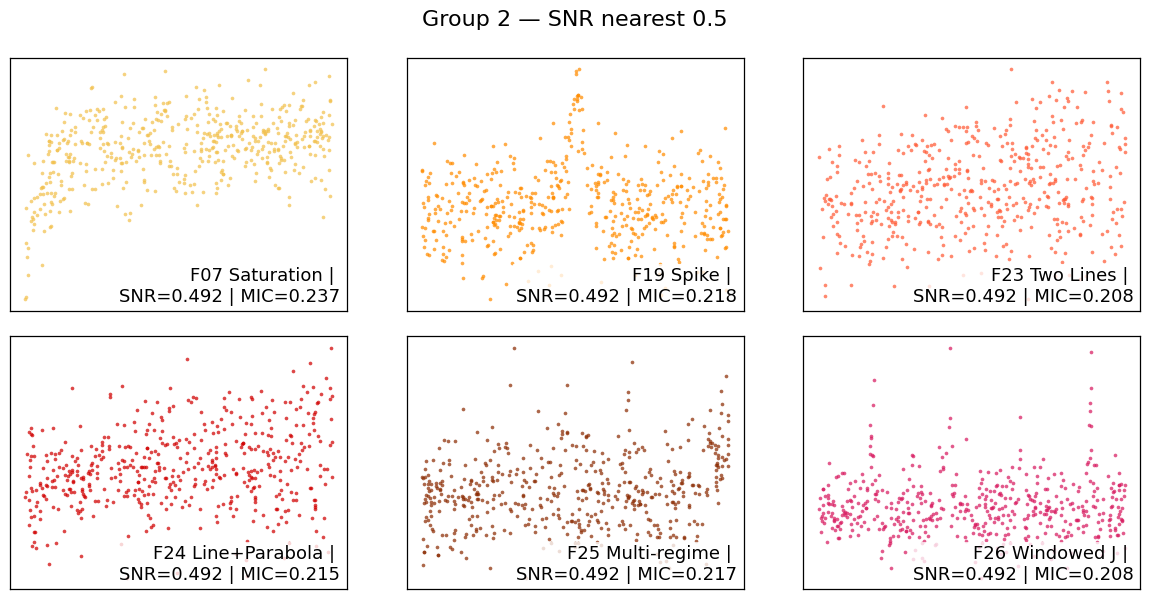

Saved 12 grouped reference figures to: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/metric_scatterplots/reference_group_grids
Saved: reference_scatterplot_cases.csv


,selection_type,selection_target,case_id,candidate_index,family_id,family_name,variant_level,repeat,nominal_snr,actual_snr,inverse_snr,MIC,level_mean_mic,group_id,subplot_row,subplot_col,figure_path
0,mean_MIC_nearest_0.8,0.8,S005122,5121,F01,Linear positive,strong,3,4.335419,4.212595,0.230658,0.791232,0.799151,group1,1,1,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,mean_MIC_nearest_0.6,0.6,S004879,4878,F01,Linear positive,strong,2,1.509463,1.400248,0.662487,0.597102,0.599138,group1,1,1,/Users/mimi/Documents/Code/Github/GSA-work/exp...
2,mean_MIC_nearest_0.4,0.4,S005318,5317,F01,Linear positive,strong,4,0.561373,0.630208,1.781345,0.400947,0.407341,group1,1,1,/Users/mimi/Documents/Code/Github/GSA-work/exp...
3,SNR_nearest_1,1.0,S005327,5326,F01,Linear positive,strong,4,1.016235,1.140844,0.984024,0.515624,0.509838,group1,1,1,/Users/mimi/Documents/Code/Github/GSA-work/exp...
4,SNR_nearest_10,10.0,S005135,5134,F01,Linear positive,strong,3,10.217053,9.927599,0.097876,0.896341,0.902819,group1,1,1,/Users/mimi/Documents/Code/Github/GSA-work/exp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,mean_MIC_nearest_0.6,0.6,S093865,93864,F22,Complex non-monotonic functions,strong,4,1.722259,1.433421,0.580633,0.595631,0.594297,group1,2,4,/Users/mimi/Documents/Code/Github/GSA-work/exp...
80,mean_MIC_nearest_0.4,0.4,S094080,94079,F22,Complex non-monotonic functions,strong,5,0.780624,0.841244,1.281026,0.393636,0.399472,group1,2,4,/Users/mimi/Documents/Code/Github/GSA-work/exp...
81,SNR_nearest_1,1.0,S094084,94083,F22,Complex non-monotonic functions,strong,5,1.016235,1.095151,0.984024,0.467741,0.463992,group1,2,4,/Users/mimi/Documents/Code/Github/GSA-work/exp...
82,SNR_nearest_10,10.0,S093438,93437,F22,Complex non-monotonic functions,strong,2,10.217053,10.578842,0.097876,0.890142,0.907182,group1,2,4,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [8]:
MIC_TARGET_SPECS = [
    (0.8, 'mean_MIC_nearest_0.8', 'MIC08'),
    (0.6, 'mean_MIC_nearest_0.6', 'MIC06'),
    (0.4, 'mean_MIC_nearest_0.4', 'MIC04'),
]
SNR_TARGET_SPECS = [
    (1.0, 'SNR_nearest_1', 'SNR1'),
    (10.0, 'SNR_nearest_10', 'SNR10'),
    (0.5, 'SNR_nearest_0.5', 'SNR05'),
]
POINTS_PATH = DATA_DIR / 'scatter_points.npz'
if not POINTS_PATH.exists():
    raise FileNotFoundError(f'Missing scatter-point archive: {POINTS_PATH}')

def select_representative_case(level_cases: pd.DataFrame) -> pd.Series:
    level_mean_mic = float(level_cases['MIC'].mean())
    representative_index = (level_cases['MIC'] - level_mean_mic).abs().idxmin()
    selected = level_cases.loc[representative_index].copy()
    selected['level_mean_mic'] = level_mean_mic
    return selected


selection_records = []
for family_id in available_families:
    family_points = plot_signal_df[plot_signal_df['family_id'] == family_id].copy()

    # For each MIC target, select the sampled SNR whose five-repeat mean MIC is closest.
    level_means = (
        family_points.groupby(['nominal_snr', 'inverse_snr'], as_index=False, dropna=False)['MIC']
        .mean()
        .rename(columns={'MIC': 'level_mean_mic'})
    )
    for target_mic, selection_type, _ in MIC_TARGET_SPECS:
        target_level = level_means.loc[(level_means['level_mean_mic'] - target_mic).abs().idxmin()]
        target_cases = family_points[np.isclose(
            family_points['inverse_snr'], float(target_level['inverse_snr']), rtol=0.0, atol=1e-15,
        )]
        selected = select_representative_case(target_cases)
        selected['selection_type'] = selection_type
        selected['selection_target'] = target_mic
        selection_records.append(selected)

    # At every requested finite SNR, select the nearest sampled level and its representative repeat.
    finite_levels = family_points.loc[np.isfinite(family_points['nominal_snr']), 'nominal_snr'].drop_duplicates()
    for target_snr, selection_type, _ in SNR_TARGET_SPECS:
        selected_snr = float(finite_levels.iloc[(finite_levels - target_snr).abs().argmin()])
        snr_cases = family_points[np.isclose(
            family_points['nominal_snr'], selected_snr, rtol=0.0, atol=1e-15,
        )]
        selected = select_representative_case(snr_cases)
        selected['selection_type'] = selection_type
        selected['selection_target'] = target_snr
        selection_records.append(selected)

reference_cases = pd.DataFrame(selection_records).reset_index(drop=True)
assert len(reference_cases) == (len(MIC_TARGET_SPECS) + len(SNR_TARGET_SPECS)) * len(available_families)
assert reference_cases.groupby('selection_type')['family_id'].nunique().eq(len(available_families)).all()

selection_path = FIGURE_DIR / 'reference_scatterplot_cases.csv'
selection_columns = [
    'selection_type', 'selection_target', 'case_id', 'candidate_index',
    'family_id', 'family_name', 'variant_level', 'repeat',
    'nominal_snr', 'actual_snr', 'inverse_snr', 'MIC', 'level_mean_mic',
    'group_id', 'subplot_row', 'subplot_col', 'figure_path',
]

def format_snr_label(value: float) -> str:
    if np.isinf(value):
        return '∞'
    if value >= 100:
        return f'{value:.0f}'
    if value >= 10:
        return f'{value:.1f}'
    if value >= 1:
        return f'{value:.2f}'
    return f'{value:.3g}'


def draw_group_reference_grid(
    selected_cases: pd.DataFrame, group_id: str, group_families: list[str],
    nrows: int, ncols: int, figure_title: str, output_path: Path,
    x_points: np.ndarray, y_points: np.ndarray,
) -> dict:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    ordered = (
        selected_cases[selected_cases['family_id'].isin(group_families)]
        .assign(family_order=lambda frame: frame['family_id'].map({fid: i for i, fid in enumerate(group_families)}))
        .sort_values('family_order')
    )
    assert len(ordered) == len(group_families) == nrows * ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows))
    flat_axes = np.asarray(axes).reshape(-1)
    saved_records = {}
    for position, (ax, (_, row)) in enumerate(zip(flat_axes, ordered.iterrows())):
        point_index = int(row['candidate_index'])
        family_id = row['family_id']
        ax.scatter(
            x_points[point_index], y_points[point_index],
            s=7.0, alpha=0.72, color=FAMILY_COLORS[family_id], linewidths=0, rasterized=True,
        )
        plot_label = (
            f'{FAMILY_SHORT_LABELS[family_id]} | \n'
            f'SNR={format_snr_label(float(row["nominal_snr"]))} | MIC={row["MIC"]:.3f}'
        )
        ax.text(
            0.98, 0.02, plot_label, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=13, color='black', zorder=5,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.78, 'pad': 2.0},
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_box_aspect(0.75)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.9)
        saved_records[(row['selection_type'], row['case_id'])] = {
            'figure_path': str(output_path), 'group_id': group_id,
            'subplot_row': position // ncols + 1, 'subplot_col': position % ncols + 1,
        }

    fig.suptitle(figure_title, y=0.99, fontsize=16)
    fig.subplots_adjust(left=0.015, right=0.985, bottom=0.025, top=0.91, wspace=0.07, hspace=0.10)
    fig.savefig(output_path, dpi=300, facecolor='white', bbox_inches='tight')
    if DISPLAY_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    return saved_records


GRID_OUTPUT_DIR = FIGURE_DIR / 'reference_group_grids'
GRID_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for old_grid in GRID_OUTPUT_DIR.glob('*.png'):
    old_grid.unlink()

# Remove the superseded individual-plot directories and old contact sheets.
for old_dirname in [
    'scatterplots_nearest_mean_mic_0p8', 'scatterplots_nearest_snr_0p1',
    'scatterplots_nearest_snr_1', 'scatterplots_nearest_snr_10',
]:
    old_dir = FIGURE_DIR / old_dirname
    if old_dir.exists():
        shutil.rmtree(old_dir)
for old_sheet in [
    'scatterplots_nearest_mean_mic_0p8.png', 'scatterplots_nearest_snr_0p1.png',
]:
    (FIGURE_DIR / old_sheet).unlink(missing_ok=True)

REFERENCE_GROUPS = [
    ('group1', PRIMARY_GROUP, 2, 4),
    ('group2', REMAINING_GROUP, 2, 3),
]
PLOT_CONDITIONS = [
    *[(selection_type, prefix, f'Mean MIC nearest {target:g}')
      for target, selection_type, prefix in MIC_TARGET_SPECS],
    *[(selection_type, prefix, f'SNR nearest {target:g}')
      for target, selection_type, prefix in SNR_TARGET_SPECS],
]

reference_figure_records = {}
with np.load(POINTS_PATH) as point_archive:
    x_points = point_archive['x']
    y_points = point_archive['y']
    for selection_type, filename_prefix, condition_title in PLOT_CONDITIONS:
        selected_cases = reference_cases[reference_cases['selection_type'] == selection_type]
        for group_id, group_families, nrows, ncols in REFERENCE_GROUPS:
            output_path = GRID_OUTPUT_DIR / f'{filename_prefix}_{group_id}_{nrows}x{ncols}.png'
            reference_figure_records.update(draw_group_reference_grid(
                selected_cases, group_id, group_families, nrows, ncols,
                f'Group {group_id[-1]} — {condition_title}', output_path, x_points, y_points,
            ))

reference_cases['group_id'] = [
    reference_figure_records[(row['selection_type'], row['case_id'])]['group_id']
    for _, row in reference_cases.iterrows()
]
reference_cases['subplot_row'] = [
    reference_figure_records[(row['selection_type'], row['case_id'])]['subplot_row']
    for _, row in reference_cases.iterrows()
]
reference_cases['subplot_col'] = [
    reference_figure_records[(row['selection_type'], row['case_id'])]['subplot_col']
    for _, row in reference_cases.iterrows()
]
reference_cases['figure_path'] = [
    reference_figure_records[(row['selection_type'], row['case_id'])]['figure_path']
    for _, row in reference_cases.iterrows()
]
reference_cases[selection_columns].to_csv(selection_path, index=False)

saved_grid_paths = sorted(GRID_OUTPUT_DIR.glob('*.png'))
assert len(reference_figure_records) == len(reference_cases) == 84
assert len(saved_grid_paths) == len(PLOT_CONDITIONS) * len(REFERENCE_GROUPS) == 12
assert all(path.stat().st_size > 0 for path in saved_grid_paths)
assert selection_path.exists() and selection_path.stat().st_size > 0
print(f'Saved {len(saved_grid_paths)} grouped reference figures to: {GRID_OUTPUT_DIR}')
print(f'Saved: {selection_path.name}')
display(reference_cases[selection_columns])

## Saved output folder

In [9]:
print(f'All figures are saved in: {FIGURE_DIR}')

All figures are saved in: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/metric_scatterplots
